##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [ ]:
# Provide your solution here

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel

In [4]:
MODEL_ID = "facebook/dinov2-small"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)

model = AutoModel.from_pretrained(MODEL_ID).to(device)

model.eval()

print(f"Model loaded on {device}")

/Users/anfalbamardouf/Downloads/HW_CV_lab/arti560-computer-vision-labs/dinov2_env/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Model loaded on cpu


In [7]:
from datasets import load_dataset
import os

dataset = load_dataset("pcuenq/oxford-pets")

os.makedirs("data_lab10", exist_ok=True)

cat_count = 0
dog_count = 0

for sample in dataset["train"]:

    image = sample["image"]
    label = sample["label"]

    # Cats تبدأ بحرف كبير
    if label[0].isupper() and cat_count < 10:
        image.save(f"data_lab10/cat_{cat_count+1}.jpg")
        cat_count += 1

    # Dogs تبدأ بحرف صغير
    elif label[0].islower() and dog_count < 10:
        image.save(f"data_lab10/dog_{dog_count+1}.jpg")
        dog_count += 1

    if cat_count == 10 and dog_count == 10:
        break

print("Cats:", cat_count)
print("Dogs:", dog_count)
print(os.listdir("data_lab10"))

Cats: 10
Dogs: 10
['dog_10.jpg', 'dog_9.jpg', 'dog_8.jpg', 'cat_10.jpg', 'cat_8.jpg', 'cat_9.jpg', 'cat_1.jpg', 'cat_2.jpg', 'cat_3.jpg', 'cat_7.jpg', 'cat_6.jpg', 'cat_4.jpg', 'cat_5.jpg', 'dog_6.jpg', 'dog_7.jpg', 'dog_5.jpg', 'dog_4.jpg', 'dog_1.jpg', 'dog_3.jpg', 'dog_2.jpg']


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

def get_global_embedding(path):
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

# Extract the 384-dimensional CLS tokens
    cls_token = outputs.last_hidden_state[:, 0]
    return F.normalize(cls_token, p=2, dim=1)


image_paths = []
true_labels = []

for i in range(1, 11):
    image_paths.append(f"data_lab10/cat_{i}.jpg")
    true_labels.append(0)

for i in range(1, 11):
    image_paths.append(f"data_lab10/dog_{i}.jpg")
    true_labels.append(1)

# Group based on mathematical similarity
embeddings = []

for path in image_paths:
    emb = get_global_embedding(path)
    embeddings.append(emb.cpu().numpy().flatten())

embeddings = np.array(embeddings)

# Apply KMeans (n=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(embeddings)

# Compare predicted clusters against ground-truth labels
print("True Labels:")
print(true_labels)

print("\nPredicted Clusters:")
print(predicted_clusters)

acc1 = accuracy_score(true_labels, predicted_clusters)
acc2 = accuracy_score(true_labels, 1 - predicted_clusters)

best_acc = max(acc1, acc2)

print(f"\nBest Clustering Accuracy: {best_acc:.2f}")

True Labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Predicted Clusters:
[1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0]

Best Clustering Accuracy: 0.75


/Users/anfalbamardouf/Downloads/HW_CV_lab/arti560-computer-vision-labs/dinov2_env/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


The clustering achieved 75% accuracy, showing that DINOv2 was generally able to separate cats and dogs correctly using CLS embeddings. However, some images were clustered incorrectly because certain cat and dog breeds share similar visual features such as fur texture, color, and shape. In addition, different backgrounds and image conditions may have affected the embeddings.

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [ ]:
# Provide your solution here

In [9]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch
import matplotlib.pyplot as plt

In [10]:
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)

model.eval()

print(f"Classification model loaded on {device}")

/Users/anfalbamardouf/Downloads/HW_CV_lab/arti560-computer-vision-labs/dinov2_env/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Classification model loaded on cpu


In [13]:
image_path = "coffeemug_Ex.2.jpg.webp"

Predicted class: coffee mug


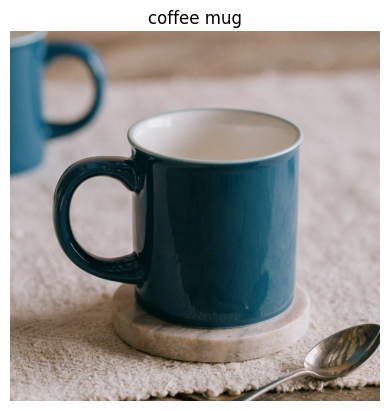

In [14]:
image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predicted_class_id = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_id]

print("Predicted class:", predicted_label)

plt.imshow(image)
plt.axis("off")
plt.title(predicted_label)
plt.show()